<div dir="rtl" style="text-align: right;">
تمرین اول :بهبود ﮐﯿﻔﯿﺖ ﺗﺼﻮﯾﺮ ﺑﻪ ﮐﻤﮏ ﻋﻤﻠﮕﺮ ﻫﺎي ﻧﻘﻄﻪ اي و ﺗﻐﯿﯿﺮ ﻫﯿﺴﺘﻮﮔﺮام
</div>

In [31]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import cv2

INPUT_DIR = "Input_Images"
image_names = ['BrightImage.jpg', 'DarkImage.jpg']

print(image_names)

['BrightImage.jpg', 'DarkImage.jpg']


In [32]:
def load_gray(name):
    return cv2.imread(os.path.join(INPUT_DIR, name), cv2.IMREAD_GRAYSCALE)

def save_gray(arr, path):
    cv2.imwrite(path, arr)

def show_images(imgs, titles, suptitle=None):
    n = len(imgs)
    plt.figure(figsize=(4 * n, 4))
    
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(imgs[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
        
    if suptitle:
        plt.suptitle(suptitle)
        
    plt.tight_layout()
    plt.show()

BrightImage.jpg -> shape: (400, 600)  min: 105  max: 228
DarkImage.jpg -> shape: (438, 827)  min: 0  max: 235


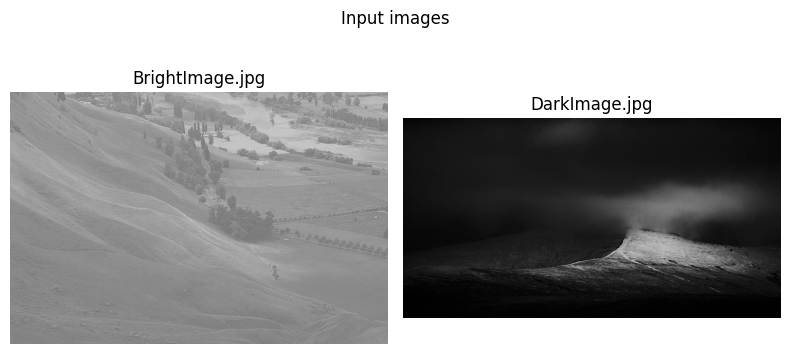

In [33]:
for name in image_names:
    arr = load_gray(name)
    print(name, "-> shape:", arr.shape, " min:", arr.min(), " max:", arr.max())

show_images([load_gray(n) for n in image_names], image_names,"Input images")


<div dir="rtl" style="text-align: right;">
قسمت 1 - I-40 , I-20 , I+20 , I+40 و پیدا کردن b بهینه
</div>


BrightImage.jpg  mean = 148.01


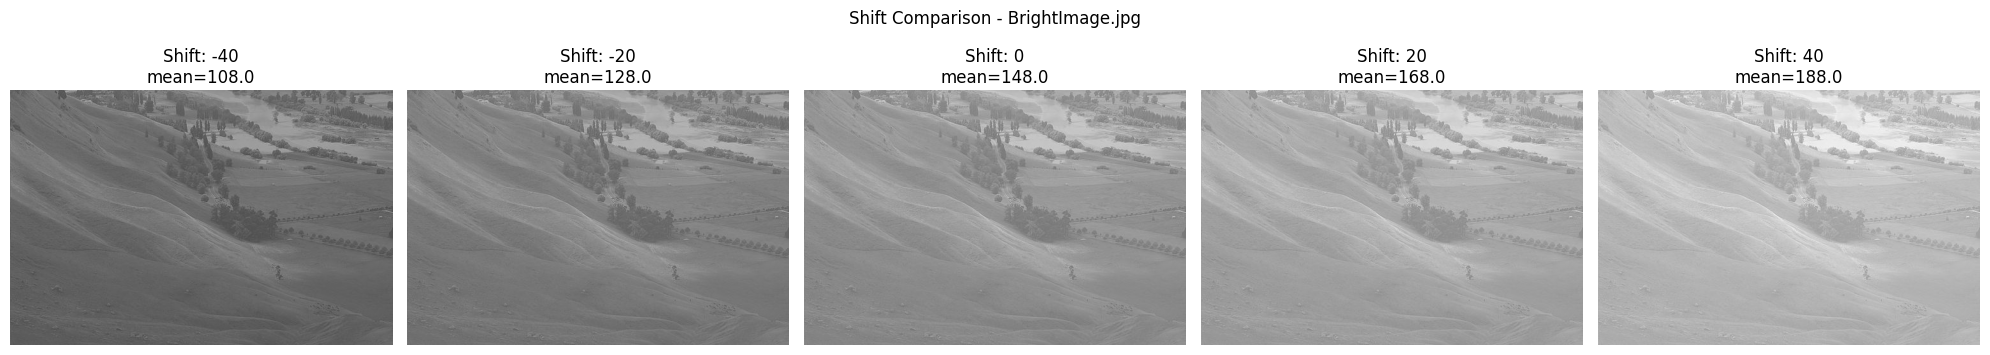

بهترین شیفت از بین ۵ حالت: -20 (میانگین نزدیک به 127.5)
b بهینه = -20.51


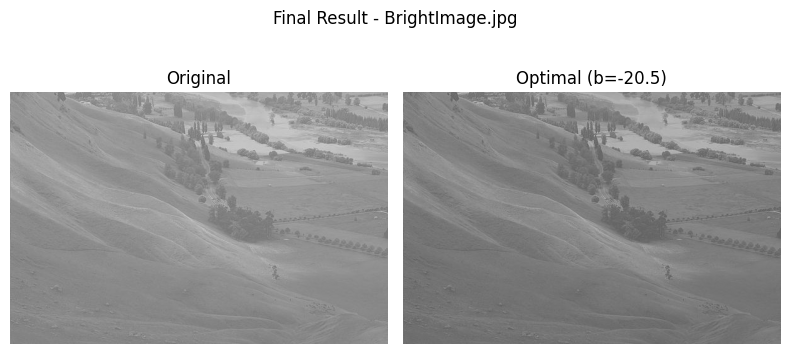


DarkImage.jpg  mean = 32.18


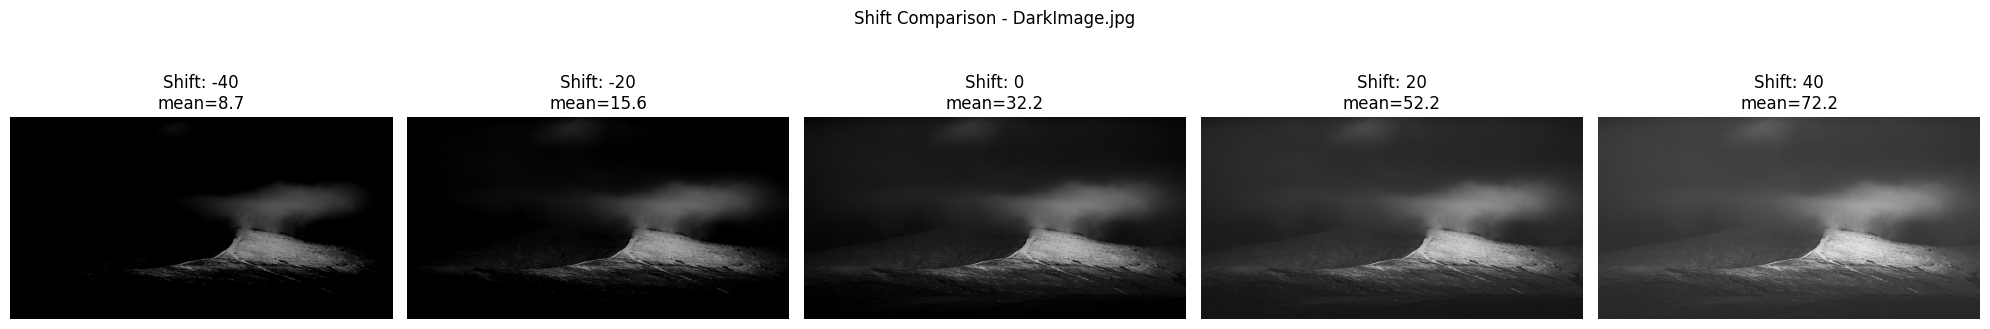

بهترین شیفت از بین ۵ حالت: 40 (میانگین نزدیک به 127.5)
b بهینه = 95.32


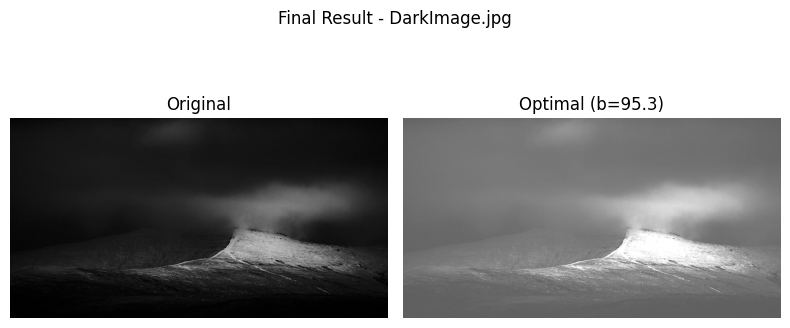

In [ ]:
OUT1 = "Output_Images/Part_1"
shifts = [-40, -20, 0, 20, 40]
TARGET_MEAN = 127.5

for name in image_names:
    I = load_gray(name)
    base = name.split(".")[0]
    print(name, " mean =", round(I.mean(), 2))

    variants = []
    titles = []
    means = {}

    I_float = I.astype(np.float64)

    for s in shifts:
        shifted = I_float + s
        shifted_clipped = np.clip(shifted, 0, 255)
        
        m = shifted_clipped.mean()
        means[s] = m
        
        variants.append(shifted_clipped)
        titles.append(f"Shift: {s}\nmean={m:.1f}")
        
        if s != 0:
            save_gray(shifted_clipped, f"{OUT1}/{base}_shift_{s}.jpg")

    show_images(variants, titles, f"Shift Comparison - {name}")

    best_s = min(shifts, key=lambda s: abs(means[s] - TARGET_MEAN))
    print(f"بهترین شیفت از بین ۵ حالت: {best_s} (میانگین نزدیک به {TARGET_MEAN})")

    b_opt = TARGET_MEAN - I_float.mean()
    print("b بهینه =", round(b_opt, 2))
    
    I_opt = np.clip(I_float + b_opt, 0, 255)
    save_gray(I_opt, f"{OUT1}/{base}_optimal_b.jpg")
    
    show_images([I, I_opt], ["Original", f"Optimal (b={b_opt:.1f})"], f"Final Result - {name}")
    print()

<div dir="rtl" style="text-align: right;">
قسمت 2 - 0.5I , 0.75I , 1.25I , 1.5I و پیدا کردن a بهینه
</div>

BrightImage.jpg  mean = 148.01


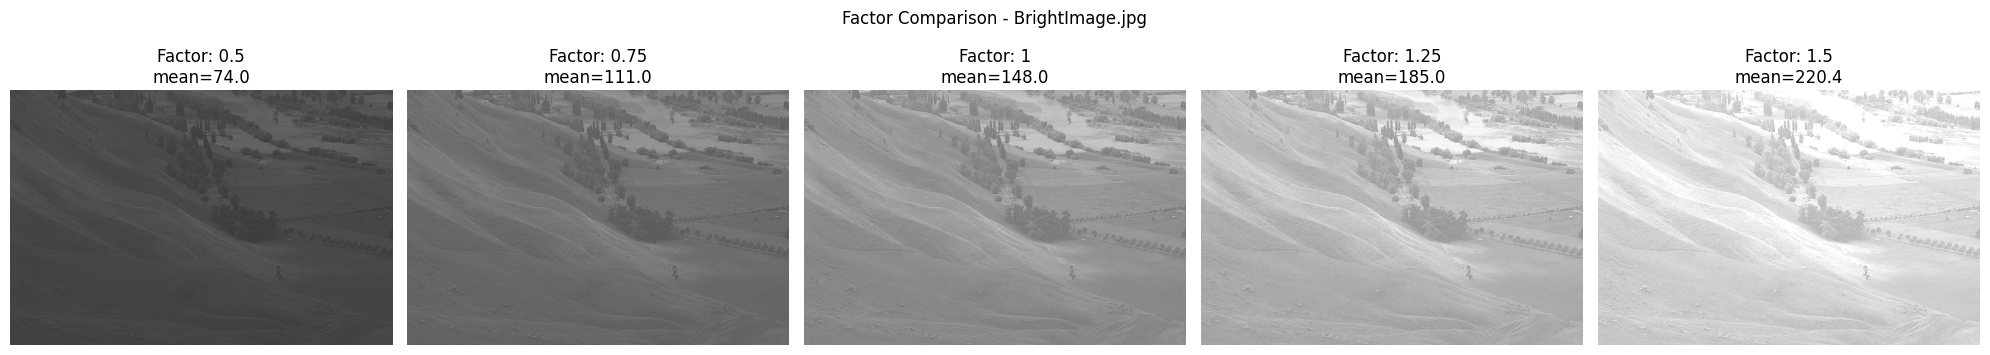

بهترین ضریب از بین ۵ حالت: a = 0.75
a بهینه = 0.861


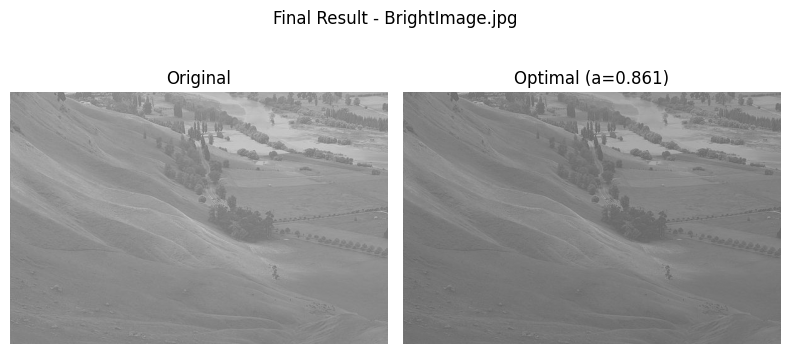


DarkImage.jpg  mean = 32.18


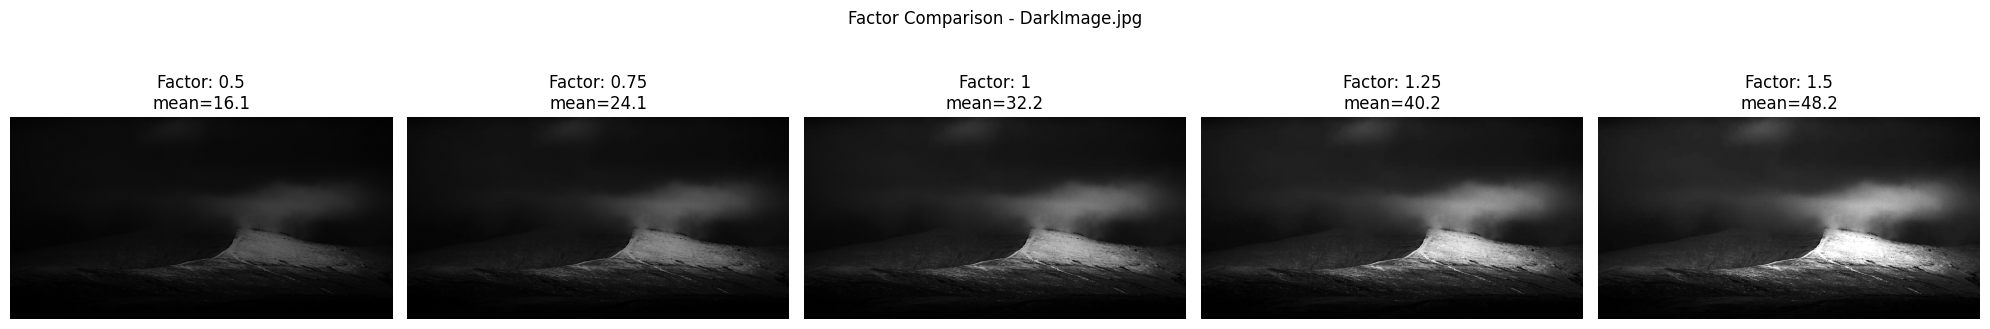

بهترین ضریب از بین ۵ حالت: a = 1.5
a بهینه = 3.962


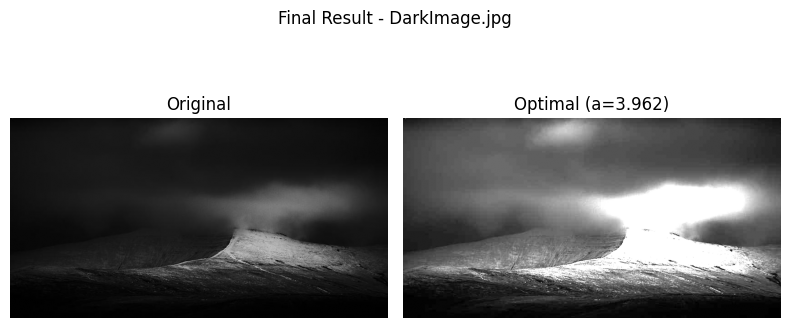

In [ ]:
OUT2 = "Output_Images/Part_2"
factors = [0.5, 0.75, 1, 1.25, 1.5]

for name in image_names:
    I = load_gray(name)
    base = name.split(".")[0]
    print(name, " mean =", round(I.mean(), 2))

    variants = []
    titles = []
    means = {}

    I_float = I.astype(np.float64)

    for a in factors:
        scaled = a * I_float
        scaled_clipped = np.clip(scaled, 0, 255)
        
        m = scaled_clipped.mean()
        means[a] = m
        
        variants.append(scaled_clipped)
        titles.append(f"Factor: {a}\nmean={m:.1f}")
        
        if a != 1:
            save_gray(scaled_clipped, f"{OUT2}/{base}_factor_{a}.jpg")

    show_images(variants, titles, f"Factor Comparison - {name}")

    best_a = min(factors, key=lambda a: abs(means[a] - TARGET_MEAN))
    print(f"بهترین ضریب از بین ۵ حالت: a = {best_a}")

    a_opt = TARGET_MEAN / I_float.mean()
    print("a بهینه =", round(a_opt, 3))
    
    I_opt = np.clip(a_opt * I_float, 0, 255)
    save_gray(I_opt, f"{OUT2}/{base}_optimal_a.jpg")
    

    show_images([I, I_opt], ["Original", f"Optimal (a={a_opt:.3f})"], f"Final Result - {name}")
    print()

<div dir="rtl" style="text-align: right;">
 قسمت 3 - بهینه‌سازی همزمان a و b
</div>

معادلات:
```
a*min + b = 0
a*max + b = 255
```
که از حل این دو معادله:
```
a_opt = 255 / (max - min)
b_opt = -a_opt * min
```


BrightImage.jpg
min, max : 105 228
a بهینه = 2.073    b بهینه = -217.68


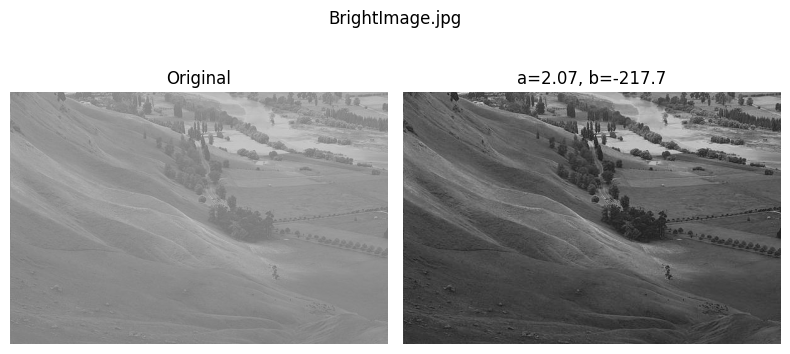


DarkImage.jpg
min, max : 0 235
a بهینه = 1.085    b بهینه = -0.0


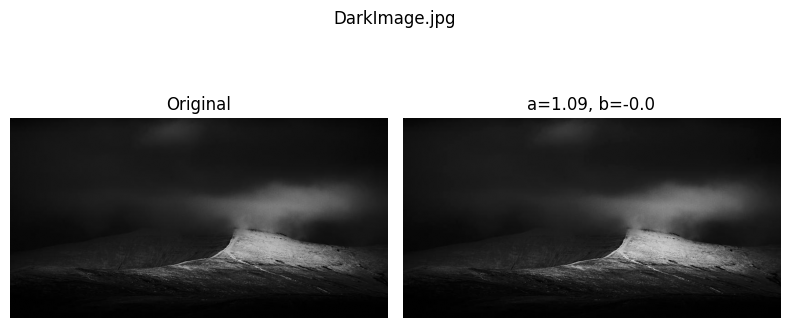

In [36]:
OUT3 = "Output_Images/Part_3"

for name in image_names:
    I = load_gray(name)
    base = name.split(".")[0]
    mn, mx = I.min(), I.max()

    a_opt = 255.0 / (mx - mn)
    b_opt = -a_opt * mn

    print(name)
    print("min, max :", mn, mx)
    print("a بهینه =", round(a_opt, 3), "   b بهینه =", round(b_opt, 2))

    I_opt = a_opt * I + b_opt
    save_gray(I_opt, f"{OUT3}/{base}_optimal_aI+b.jpg")
    show_images([I, I_opt], ["Original", f"a={a_opt:.2f}, b={b_opt:.1f}"], name)
    print()



<div dir="rtl" style="text-align: right;">
قسمت 4 - تبدیل توانی (gamma)
</div>

```
I_gamma = 255 * (I/255) ** gamma
```


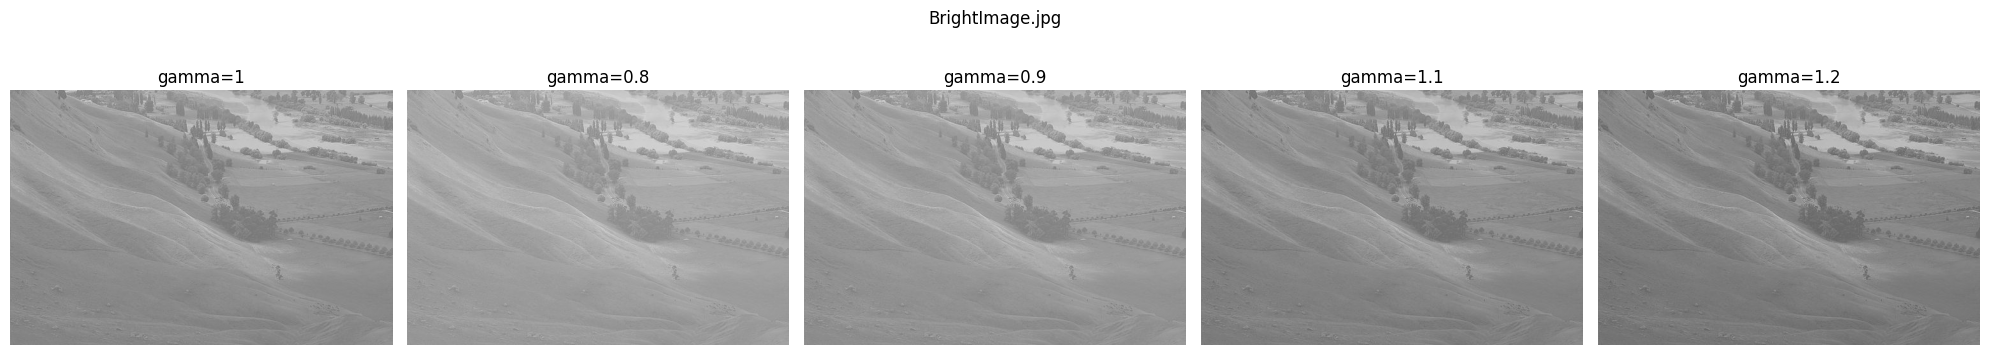

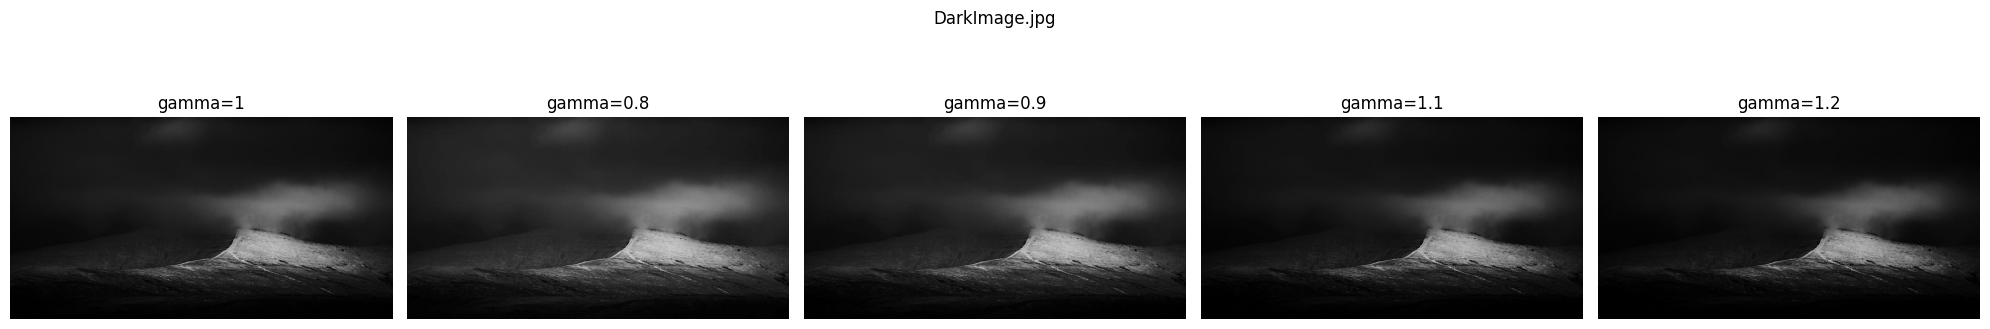

In [37]:
OUT4 = "Output_Images/Part_4"
gammas = [0.8, 0.9, 1.1, 1.2]

for name in image_names:
    I = load_gray(name)
    base = name.split(".")[0]
    I_norm = I / 255.0

    variants, titles = [I], ["gamma=1"] #(اصلی)
    for g in gammas:
        I_g = 255.0 * (I_norm ** g)
        save_gray(I_g, f"{OUT4}/{base}_I^{g}.jpg")
        variants.append(I_g)
        titles.append(f"gamma={g}")

    show_images(variants, titles, name)


<div dir="rtl" style="text-align: right;">
قسمت 5 - هیستوگرام و Histogram Equalization
</div>


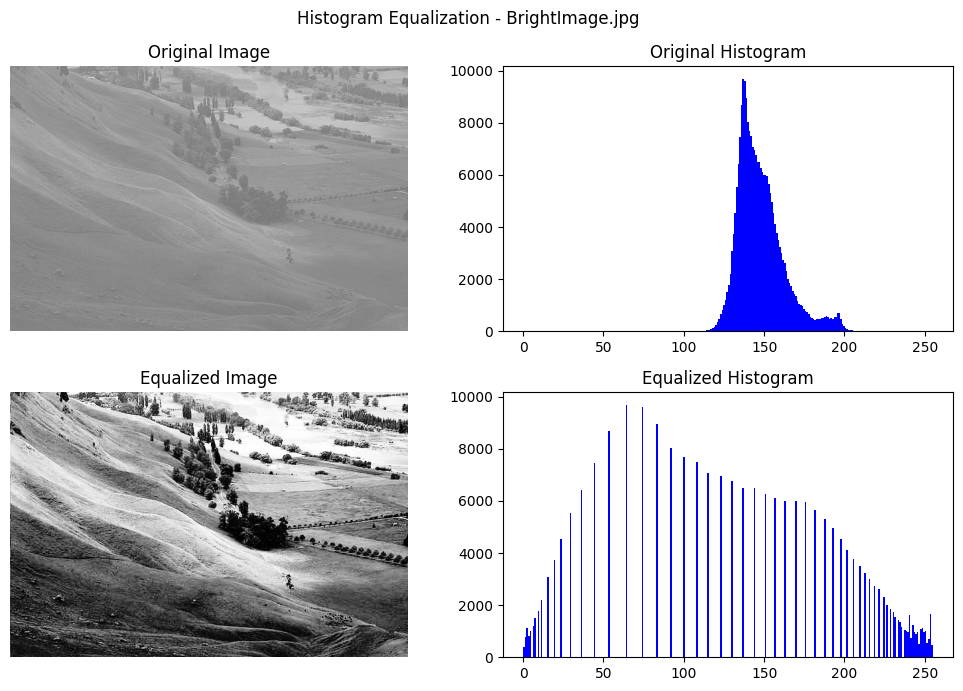

BrightImage.jpg
  قبل از پردازش (mean / std)        : 148.01 / 14.76
  بعد از Equalization (mean / std) : 130.45 / 72.9
  بعد از a*I+b قسمت ۳ (mean / std) : 89.16 / 30.59



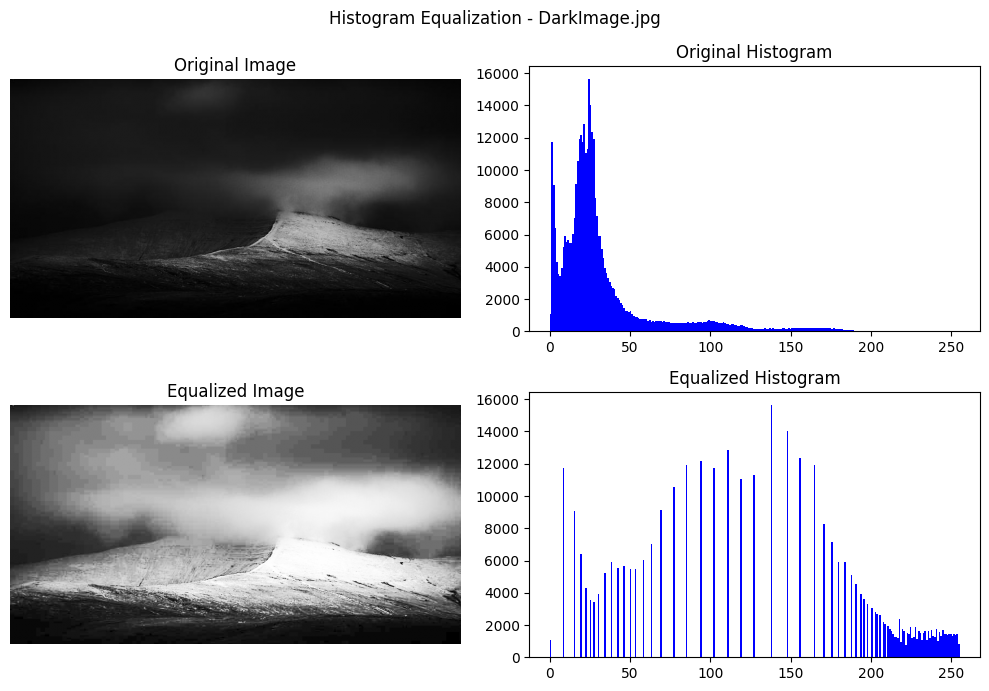

DarkImage.jpg
  قبل از پردازش (mean / std)        : 32.18 / 32.34
  بعد از Equalization (mean / std) : 129.89 / 73.07
  بعد از a*I+b قسمت ۳ (mean / std) : 34.92 / 35.1



In [ ]:
OUT5 = "Output_Images/Part_5"

def histogram_equalize(arr):
    arr_int = arr.astype(np.uint8)
    hist, _ = np.histogram(arr_int.flatten(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    
    cdf_min = cdf[cdf > 0].min()
    n = arr_int.size
    
    # CDF
    mapping = np.round((cdf - cdf_min) / (n - cdf_min) * 255)
    mapping = np.clip(mapping, 0, 255).astype(np.uint8)
    
    return mapping[arr_int].astype(np.float64)


stats_part3 = {}
for name in image_names:
    I = load_gray(name).astype(np.float64)
    mn, mx = I.min(), I.max()
    a_opt = 255.0 / (mx - mn)
    b_opt = -a_opt * mn
    stats_part3[name] = np.clip(a_opt * I + b_opt, 0, 255)

for name in image_names:
    I = load_gray(name)
    base = name.split(".")[0]
    
    I_eq = histogram_equalize(I)
    save_gray(I_eq, f"{OUT5}/{base}_equalized.jpg")


    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    

    axes[0, 0].imshow(I, cmap="gray", vmin=0, vmax=255)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")
    

    axes[0, 1].hist(I.flatten(), bins=256, range=(0, 255), color="blue")
    axes[0, 1].set_title("Original Histogram")
    

    axes[1, 0].imshow(I_eq, cmap="gray", vmin=0, vmax=255)
    axes[1, 0].set_title("Equalized Image")
    axes[1, 0].axis("off")
    

    axes[1, 1].hist(I_eq.flatten(), bins=256, range=(0, 255), color="blue")
    axes[1, 1].set_title("Equalized Histogram")
    
    fig.suptitle(f"Histogram Equalization - {name}")
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.hist(I.flatten(), bins=256, range=(0, 255), color="blue")
    plt.title(f"Histogram - {name}")
    plt.savefig(f"{OUT5}/{base}_histogram.png")
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.hist(I_eq.flatten(), bins=256, range=(0, 255), color="blue")
    plt.title(f"Equalized Histogram - {name}")
    plt.savefig(f"{OUT5}/{base}_equalized_histogram.png")
    plt.close()


    print(name)
    print("  قبل از پردازش (mean / std)        :", round(I.mean(), 2), "/", round(I.std(), 2))
    print("  بعد از Equalization (mean / std) :", round(I_eq.mean(), 2), "/", round(I_eq.std(), 2))
    print("  بعد از a*I+b قسمت ۳ (mean / std) :", round(stats_part3[name].mean(), 2), "/", round(stats_part3[name].std(), 2))
    print()